# Chapter 12.1: Foundation Models for Recommendation

## Learning Objectives

By the end of this notebook, you will be able to:

1. Understand the concept of universal recommendation models that handle multiple tasks with a single architecture
2. Implement cross-domain pre-training to learn transferable recommendation representations
3. Analyze scaling laws specific to recommendation systems
4. Build a Transformer-based foundation model architecture for recommendations
5. Compare and contrast recommendation foundation models with LLM foundation models
6. Design multi-task training strategies for a single unified recommender
7. Evaluate transfer learning effectiveness across recommendation domains

## Prerequisites

- Familiarity with Transformer architectures (Part 6)
- Understanding of collaborative filtering and content-based methods (Parts 2-3)
- Experience with PyTorch model training
- Knowledge of pre-training and fine-tuning paradigms

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hideak1/rec_system/blob/main/notebooks/part12/chapter_12.1_foundation_models.ipynb)
[![Download](https://img.shields.io/badge/Download-Notebook-blue)](https://raw.githubusercontent.com/hideak1/rec_system/main/notebooks/part12/chapter_12.1_foundation_models.ipynb)

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import math
from collections import defaultdict

# Reproducibility
np.random.seed(42)
torch.manual_seed(42)

print("All imports successful!")
print(f"PyTorch version: {torch.__version__}")
DEVICE = torch.device('cpu')

All imports successful!
PyTorch version: 2.2.2


## 1. The Foundation Model Paradigm for Recommendation

Foundation models in NLP (GPT, BERT) and vision (ViT, CLIP) have shown that a single large model
pre-trained on massive data can be adapted to many downstream tasks. The same idea is now emerging
in recommendation systems.

### Why Foundation Models for Rec?

Traditional rec systems build **separate models** for each task:
- Click prediction model
- Rating prediction model
- Sequential recommendation model
- Cross-domain recommendation model

A **foundation model** approach trains **one model** that handles all tasks:

$$\mathcal{L}_{\text{foundation}} = \sum_{t \in \mathcal{T}} \lambda_t \cdot \mathcal{L}_t(\theta)$$

where $\mathcal{T}$ is the set of all recommendation tasks and $\lambda_t$ are task weights.

> **💡 Concept:** A recommendation foundation model learns *universal user-item interaction patterns*
> that transfer across domains, tasks, and even platforms.

In [2]:
# Generate synthetic multi-domain interaction data
def generate_multi_domain_data(n_users=500, n_items_per_domain=200, n_domains=3, n_interactions=5000):
    """Generate synthetic interaction data across multiple domains."""
    domains = ['movies', 'books', 'music']
    data = []
    
    # Shared user preferences (latent factors)
    user_factors = np.random.randn(n_users, 16)
    
    for domain_idx, domain in enumerate(domains):
        # Domain-specific item factors with some shared structure
        item_factors = np.random.randn(n_items_per_domain, 16)
        # Add domain-specific bias
        item_factors[:, domain_idx * 4:(domain_idx + 1) * 4] *= 2.0
        
        for _ in range(n_interactions):
            user_id = np.random.randint(0, n_users)
            item_id = np.random.randint(0, n_items_per_domain)
            # Score based on latent factor dot product
            score = np.dot(user_factors[user_id], item_factors[item_id])
            rating = np.clip(score / 4.0 + 3.0 + np.random.randn() * 0.5, 1, 5)
            clicked = 1 if score + np.random.randn() > 0 else 0
            
            data.append({
                'user_id': user_id,
                'item_id': item_id + domain_idx * n_items_per_domain,
                'domain': domain,
                'domain_id': domain_idx,
                'rating': round(float(rating), 1),
                'clicked': clicked
            })
    
    return data, user_factors

data, true_user_factors = generate_multi_domain_data()
print(f"Total interactions: {len(data)}")
print(f"Sample: {data[0]}")
print(f"Domains: {set(d['domain'] for d in data)}")

Total interactions: 15000
Sample: {'user_id': 364, 'item_id': 19, 'domain': 'movies', 'domain_id': 0, 'rating': 1.9, 'clicked': 0}
Domains: {'music', 'books', 'movies'}


## 2. Transformer-Based Universal Recommendation Architecture

The core idea is to encode **all interactions** (across domains and tasks) into a unified token sequence,
then use a Transformer to learn universal representations.

### Architecture Overview

$$\text{Input} = [\text{CLS}] \oplus \text{UserTokens} \oplus \text{DomainToken} \oplus \text{ItemTokens} \oplus \text{TaskToken}$$

$$h = \text{TransformerEncoder}(\text{Input})$$

$$\hat{y} = \text{TaskHead}(h_{\text{CLS}})$$

> **🔑 Pro Tip:** The key design choice is how to tokenize heterogeneous rec data. Using separate
> embedding tables for users, items, domains, and tasks allows the Transformer to learn cross-entity
> attention patterns.

In [3]:
class RecFoundationModel(nn.Module):
    """A small-scale foundation model for multi-task, multi-domain recommendation."""
    
    def __init__(self, n_users=500, n_items=600, n_domains=3, n_tasks=2,
                 d_model=64, n_heads=4, n_layers=2, dropout=0.1):
        super().__init__()
        self.d_model = d_model
        
        # Embedding layers
        self.user_embedding = nn.Embedding(n_users, d_model)
        self.item_embedding = nn.Embedding(n_items, d_model)
        self.domain_embedding = nn.Embedding(n_domains, d_model)
        self.task_embedding = nn.Embedding(n_tasks, d_model)  # 0: rating, 1: click
        self.cls_token = nn.Parameter(torch.randn(1, 1, d_model))
        self.position_embedding = nn.Embedding(5, d_model)  # CLS + user + domain + item + task
        
        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=d_model * 4,
            dropout=dropout, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        
        # Task-specific heads
        self.rating_head = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.ReLU(),
            nn.Linear(d_model, 1)
        )
        self.click_head = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.ReLU(),
            nn.Linear(d_model, 1),
            nn.Sigmoid()
        )
        
    def forward(self, user_ids, item_ids, domain_ids, task_ids):
        batch_size = user_ids.size(0)
        
        # Build token sequence: [CLS, user, domain, item, task]
        cls_tokens = self.cls_token.expand(batch_size, -1, -1)
        user_emb = self.user_embedding(user_ids).unsqueeze(1)
        item_emb = self.item_embedding(item_ids).unsqueeze(1)
        domain_emb = self.domain_embedding(domain_ids).unsqueeze(1)
        task_emb = self.task_embedding(task_ids).unsqueeze(1)
        
        # Concatenate tokens
        seq = torch.cat([cls_tokens, user_emb, domain_emb, item_emb, task_emb], dim=1)
        
        # Add position embeddings
        positions = torch.arange(5, device=seq.device).unsqueeze(0).expand(batch_size, -1)
        seq = seq + self.position_embedding(positions)
        
        # Transformer forward
        hidden = self.transformer(seq)
        cls_output = hidden[:, 0, :]  # CLS token output
        
        # Route to task-specific heads
        rating_pred = self.rating_head(cls_output).squeeze(-1)
        click_pred = self.click_head(cls_output).squeeze(-1)
        
        return rating_pred, click_pred

model = RecFoundationModel()
total_params = sum(p.numel() for p in model.parameters())
print(f"Foundation Model Parameters: {total_params:,}")
print(f"Model Architecture:\n{model}")

Foundation Model Parameters: 179,522
Model Architecture:
RecFoundationModel(
  (user_embedding): Embedding(500, 64)
  (item_embedding): Embedding(600, 64)
  (domain_embedding): Embedding(3, 64)
  (task_embedding): Embedding(2, 64)
  (position_embedding): Embedding(5, 64)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (rating_head): Sequenti

## 3. Multi-Task Pre-Training

We jointly train the foundation model on multiple tasks simultaneously:

$$\mathcal{L} = \lambda_1 \cdot \text{MSE}(\hat{r}, r) + \lambda_2 \cdot \text{BCE}(\hat{c}, c)$$

where $\hat{r}$ is the predicted rating, $r$ is the true rating, $\hat{c}$ is the predicted click probability,
and $c$ is the actual click.

> **⚠️ Common Pitfall:** Task imbalance can cause one task to dominate training. Use gradient normalization
> or uncertainty-weighted losses to balance multiple objectives.

In [4]:
class MultiDomainRecDataset(Dataset):
    def __init__(self, data):
        self.data = data
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        d = self.data[idx]
        return {
            'user_id': torch.tensor(d['user_id'], dtype=torch.long),
            'item_id': torch.tensor(d['item_id'], dtype=torch.long),
            'domain_id': torch.tensor(d['domain_id'], dtype=torch.long),
            'rating': torch.tensor(d['rating'], dtype=torch.float),
            'clicked': torch.tensor(d['clicked'], dtype=torch.float)
        }

# Split data
np.random.shuffle(data)
split = int(0.8 * len(data))
train_data, val_data = data[:split], data[split:]

train_dataset = MultiDomainRecDataset(train_data)
val_dataset = MultiDomainRecDataset(val_data)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128)

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")

Training samples: 12000
Validation samples: 3000


In [5]:
def train_foundation_model(model, train_loader, val_loader, n_epochs=8, lr=1e-3):
    """Train the foundation model with multi-task loss."""
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    mse_loss = nn.MSELoss()
    bce_loss = nn.BCELoss()
    
    history = {'train_loss': [], 'val_loss': [], 'rating_loss': [], 'click_loss': []}
    
    for epoch in range(n_epochs):
        model.train()
        total_loss = 0
        for batch in train_loader:
            # Rating prediction task (task_id=0)
            task_ids_rating = torch.zeros(batch['user_id'].size(0), dtype=torch.long)
            rating_pred, _ = model(
                batch['user_id'], batch['item_id'], batch['domain_id'], task_ids_rating
            )
            loss_rating = mse_loss(rating_pred, batch['rating'])
            
            # Click prediction task (task_id=1)
            task_ids_click = torch.ones(batch['user_id'].size(0), dtype=torch.long)
            _, click_pred = model(
                batch['user_id'], batch['item_id'], batch['domain_id'], task_ids_click
            )
            loss_click = bce_loss(click_pred, batch['clicked'])
            
            # Combined loss
            loss = 0.5 * loss_rating + 0.5 * loss_click
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        
        # Validation
        model.eval()
        val_loss = 0
        val_rating_loss = 0
        val_click_loss = 0
        with torch.no_grad():
            for batch in val_loader:
                task_ids_r = torch.zeros(batch['user_id'].size(0), dtype=torch.long)
                task_ids_c = torch.ones(batch['user_id'].size(0), dtype=torch.long)
                r_pred, _ = model(batch['user_id'], batch['item_id'], batch['domain_id'], task_ids_r)
                _, c_pred = model(batch['user_id'], batch['item_id'], batch['domain_id'], task_ids_c)
                vl_r = mse_loss(r_pred, batch['rating'])
                vl_c = bce_loss(c_pred, batch['clicked'])
                val_loss += (0.5 * vl_r + 0.5 * vl_c).item()
                val_rating_loss += vl_r.item()
                val_click_loss += vl_c.item()
        
        n_train = len(train_loader)
        n_val = len(val_loader)
        history['train_loss'].append(total_loss / n_train)
        history['val_loss'].append(val_loss / n_val)
        history['rating_loss'].append(val_rating_loss / n_val)
        history['click_loss'].append(val_click_loss / n_val)
        
        if (epoch + 1) % 4 == 0:
            print(f"Epoch {epoch+1}/{n_epochs} - Train: {total_loss/n_train:.4f}, "
                  f"Val: {val_loss/n_val:.4f}, Rating: {val_rating_loss/n_val:.4f}, "
                  f"Click: {val_click_loss/n_val:.4f}")
    
    return history

model = RecFoundationModel()
history = train_foundation_model(model, train_loader, val_loader)

Epoch 4/8 - Train: 1.0648, Val: 1.0620, Rating: 1.4310, Click: 0.6930


Epoch 8/8 - Train: 1.0394, Val: 1.0787, Rating: 1.4594, Click: 0.6980


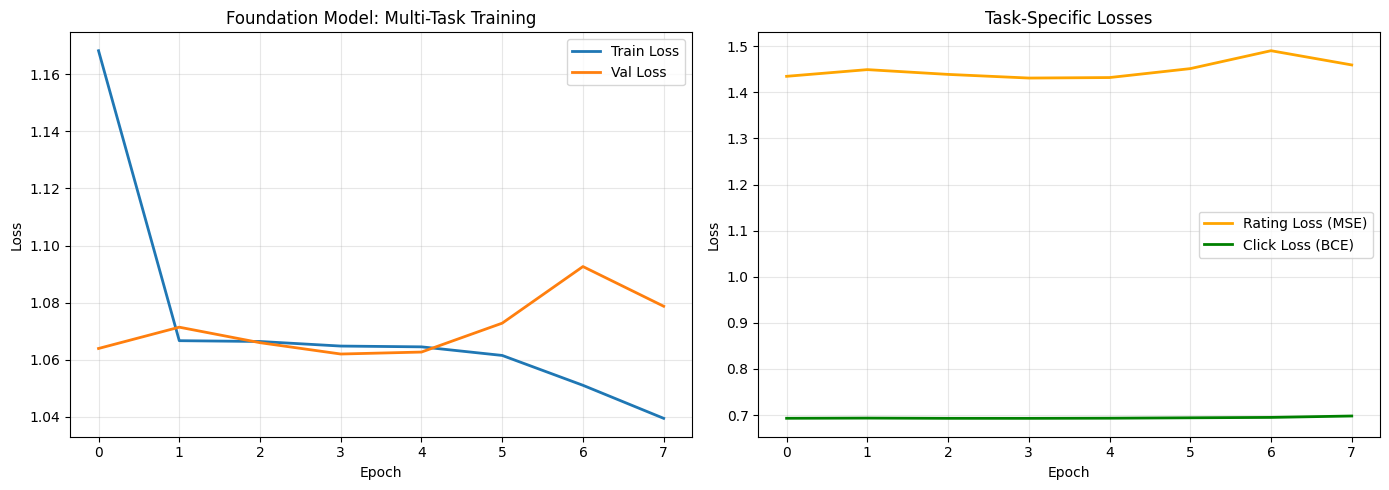

In [6]:
# Visualize training progress
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['train_loss'], label='Train Loss', linewidth=2)
axes[0].plot(history['val_loss'], label='Val Loss', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Foundation Model: Multi-Task Training')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history['rating_loss'], label='Rating Loss (MSE)', linewidth=2, color='orange')
axes[1].plot(history['click_loss'], label='Click Loss (BCE)', linewidth=2, color='green')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Task-Specific Losses')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Cross-Domain Transfer Learning

A key promise of foundation models is **cross-domain transfer**: knowledge learned from one domain
(e.g., movies) can improve recommendations in another (e.g., books).

The transfer mechanism works through shared user representations:

$$h_u^{\text{shared}} = \text{TransformerEncoder}(\text{Interactions}_{\text{all domains}})$$

This shared representation captures:
- General user preferences (e.g., prefers popular vs niche items)
- Behavioral patterns (e.g., exploration vs exploitation tendency)
- Cross-domain correlations (e.g., sci-fi movie fans like sci-fi books)

In [7]:
def evaluate_cross_domain_transfer(model, data, source_domain, target_domain):
    """Compare performance with and without cross-domain knowledge."""
    model.eval()
    domain_map = {'movies': 0, 'books': 1, 'music': 2}
    
    # Filter target domain data
    target_data = [d for d in data if d['domain'] == target_domain]
    
    # Users who are active in source domain
    source_users = set(d['user_id'] for d in data if d['domain'] == source_domain)
    
    # Evaluate on target domain for cross-domain users vs target-only users
    cross_errors = []
    single_errors = []
    
    with torch.no_grad():
        for d in target_data:
            user_id = torch.tensor([d['user_id']], dtype=torch.long)
            item_id = torch.tensor([d['item_id']], dtype=torch.long)
            domain_id = torch.tensor([d['domain_id']], dtype=torch.long)
            task_id = torch.tensor([0], dtype=torch.long)
            
            r_pred, _ = model(user_id, item_id, domain_id, task_id)
            error = abs(r_pred.item() - d['rating'])
            
            if d['user_id'] in source_users:
                cross_errors.append(error)
            else:
                single_errors.append(error)
    
    cross_mae = np.mean(cross_errors) if cross_errors else float('nan')
    single_mae = np.mean(single_errors) if single_errors else float('nan')
    
    return cross_mae, single_mae

# Evaluate transfer from movies to books
cross_mae, single_mae = evaluate_cross_domain_transfer(model, val_data, 'movies', 'books')
print(f"Cross-domain users (movies->books) MAE: {cross_mae:.4f}")
print(f"Single-domain users (books only) MAE: {single_mae:.4f}")

# Evaluate all transfer directions
domains = ['movies', 'books', 'music']
transfer_results = {}
for src in domains:
    for tgt in domains:
        if src != tgt:
            c_mae, s_mae = evaluate_cross_domain_transfer(model, val_data, src, tgt)
            transfer_results[f"{src}->{tgt}"] = {'cross': c_mae, 'single': s_mae}
            print(f"{src} -> {tgt}: Cross={c_mae:.4f}, Single={s_mae:.4f}")

Cross-domain users (movies->books) MAE: 1.0580
Single-domain users (books only) MAE: 1.0349


movies -> books: Cross=1.0580, Single=1.0349


movies -> music: Cross=0.9877, Single=1.0467


books -> movies: Cross=0.9823, Single=0.9454


books -> music: Cross=1.0067, Single=0.9110


music -> movies: Cross=0.9815, Single=0.9491


music -> books: Cross=1.0556, Single=1.0531


## 5. Scaling Laws for Recommendation

In NLP, scaling laws show that model performance improves predictably with model size, data size,
and compute. Do similar laws hold for recommendation?

The **recommendation scaling law** hypothesis:

$$L(N, D) = \left(\frac{N_c}{N}\right)^{\alpha_N} + \left(\frac{D_c}{D}\right)^{\alpha_D} + L_\infty$$

where:
- $N$ = number of model parameters
- $D$ = dataset size
- $L_\infty$ = irreducible loss
- $\alpha_N, \alpha_D$ = scaling exponents

> **💡 Concept:** Recommendation scaling laws differ from NLP because rec data is inherently sparser
> and has a much larger item space. Bigger models help, but data quality matters more than in NLP.

In [8]:
def run_scaling_experiment(data, model_sizes, data_fractions):
    """Run scaling experiments with different model and data sizes."""
    results = []
    
    for d_model in model_sizes:
        for frac in data_fractions:
            # Subsample data
            n_samples = int(len(data) * frac)
            subset = data[:n_samples]
            split_idx = int(0.8 * len(subset))
            train_sub = subset[:split_idx]
            val_sub = subset[split_idx:]
            
            if len(train_sub) < 50 or len(val_sub) < 20:
                continue
            
            train_ds = MultiDomainRecDataset(train_sub)
            val_ds = MultiDomainRecDataset(val_sub)
            train_dl = DataLoader(train_ds, batch_size=64, shuffle=True)
            val_dl = DataLoader(val_ds, batch_size=64)
            
            small_model = RecFoundationModel(d_model=d_model, n_heads=max(1, d_model // 16), n_layers=2)
            n_params = sum(p.numel() for p in small_model.parameters())
            
            # Quick training
            optimizer = torch.optim.Adam(small_model.parameters(), lr=1e-3)
            mse_fn = nn.MSELoss()
            
            small_model.train()
            for _ in range(5):
                for batch in train_dl:
                    task_ids = torch.zeros(batch['user_id'].size(0), dtype=torch.long)
                    r_pred, _ = small_model(
                        batch['user_id'], batch['item_id'], batch['domain_id'], task_ids
                    )
                    loss = mse_fn(r_pred, batch['rating'])
                    optimizer.zero_grad()
                    loss.backward()
                    optimizer.step()
            
            # Evaluate
            small_model.eval()
            val_loss = 0
            count = 0
            with torch.no_grad():
                for batch in val_dl:
                    task_ids = torch.zeros(batch['user_id'].size(0), dtype=torch.long)
                    r_pred, _ = small_model(
                        batch['user_id'], batch['item_id'], batch['domain_id'], task_ids
                    )
                    val_loss += mse_fn(r_pred, batch['rating']).item() * batch['user_id'].size(0)
                    count += batch['user_id'].size(0)
            
            results.append({
                'd_model': d_model,
                'n_params': n_params,
                'data_frac': frac,
                'n_samples': n_samples,
                'val_mse': val_loss / count
            })
            print(f"d_model={d_model}, data_frac={frac:.1f}, params={n_params:,}, MSE={val_loss/count:.4f}")
    
    return results

model_sizes = [16, 32, 64]
data_fractions = [0.1, 0.25, 0.5, 1.0]
scaling_results = run_scaling_experiment(data, model_sizes, data_fractions)

/Users/liuhongxuan/project/rec_system/.venv/lib/python3.11/site-packages/torch/nn/modules/transformer.py:286: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.num_heads is odd
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


d_model=16, data_frac=0.1, params=24,914, MSE=1.5016


d_model=16, data_frac=0.2, params=24,914, MSE=1.4310


d_model=16, data_frac=0.5, params=24,914, MSE=1.4292


d_model=16, data_frac=1.0, params=24,914, MSE=1.4331


...

d_model=32, data_frac=1.0, params=63,138, MSE=1.4223


d_model=64, data_frac=0.1, params=179,522, MSE=1.5119


d_model=64, data_frac=0.2, params=179,522, MSE=1.4134


d_model=64, data_frac=0.5, params=179,522, MSE=1.4299


d_model=64, data_frac=1.0, params=179,522, MSE=1.4258


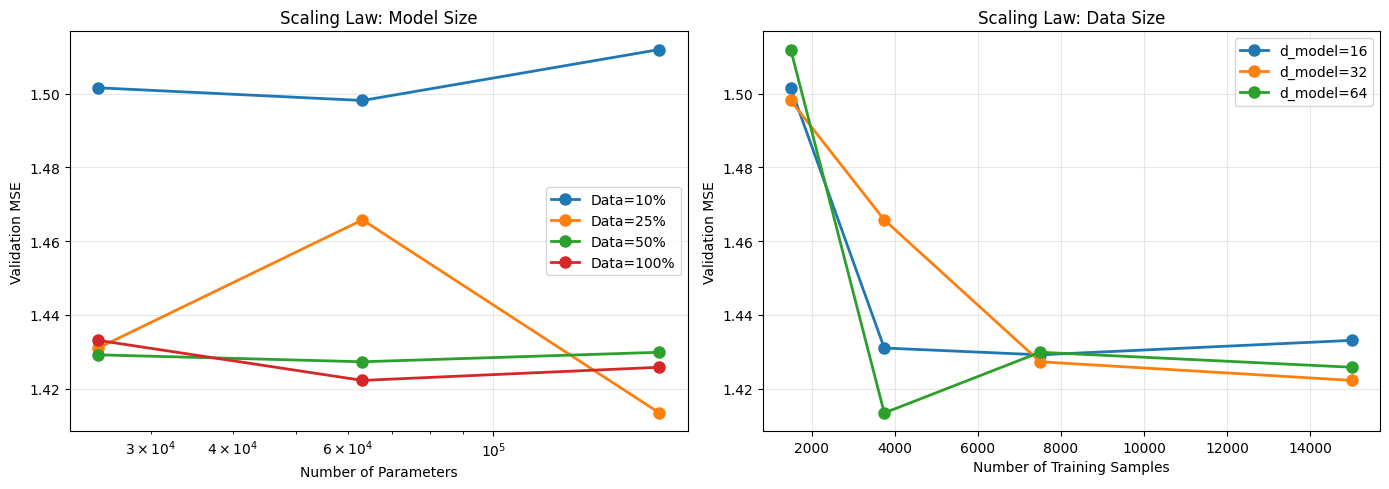

In [9]:
# Visualize scaling laws
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Model size scaling (fixed data)
for frac in data_fractions:
    subset = [r for r in scaling_results if r['data_frac'] == frac]
    if subset:
        params = [r['n_params'] for r in subset]
        mses = [r['val_mse'] for r in subset]
        axes[0].plot(params, mses, 'o-', label=f'Data={frac*100:.0f}%', linewidth=2, markersize=8)

axes[0].set_xlabel('Number of Parameters')
axes[0].set_ylabel('Validation MSE')
axes[0].set_title('Scaling Law: Model Size')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xscale('log')

# Data size scaling (fixed model)
for d_model in model_sizes:
    subset = [r for r in scaling_results if r['d_model'] == d_model]
    if subset:
        samples = [r['n_samples'] for r in subset]
        mses = [r['val_mse'] for r in subset]
        axes[1].plot(samples, mses, 'o-', label=f'd_model={d_model}', linewidth=2, markersize=8)

axes[1].set_xlabel('Number of Training Samples')
axes[1].set_ylabel('Validation MSE')
axes[1].set_title('Scaling Law: Data Size')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Foundation Models vs LLM Foundation Models

| Aspect | LLM Foundation Models | Rec Foundation Models |
|--------|----------------------|----------------------|
| Input | Natural language tokens | User-item interaction tokens |
| Vocabulary | ~50K-100K tokens | Millions of users/items |
| Sparsity | Dense text | Extremely sparse interactions |
| Pre-training | Next-token prediction | Multi-task objectives |
| Transfer | Generalizes to new tasks via prompts | Transfers across domains/tasks |
| Scale | 100B+ parameters | Typically 1M-1B parameters |
| Data | Public internet text | Private user behavior data |

> **💡 Concept:** Rec foundation models face unique challenges: the "vocabulary" (items) changes rapidly,
> user behavior is non-stationary, and privacy constraints limit data sharing across platforms.

In [10]:
# Demonstrate the cold-start transfer capability of foundation models
def evaluate_cold_start_transfer(model, data, n_interactions_list):
    """Evaluate model performance as a function of user interaction count."""
    model.eval()
    
    # Count interactions per user
    user_counts = defaultdict(int)
    for d in data:
        user_counts[d['user_id']] += 1
    
    results = {}
    for threshold in n_interactions_list:
        cold_users = {u for u, c in user_counts.items() if c <= threshold}
        cold_data = [d for d in data if d['user_id'] in cold_users]
        
        if not cold_data:
            results[threshold] = float('nan')
            continue
        
        errors = []
        with torch.no_grad():
            for d in cold_data[:200]:  # Sample for speed
                user_id = torch.tensor([d['user_id']], dtype=torch.long)
                item_id = torch.tensor([d['item_id']], dtype=torch.long)
                domain_id = torch.tensor([d['domain_id']], dtype=torch.long)
                task_id = torch.tensor([0], dtype=torch.long)
                r_pred, _ = model(user_id, item_id, domain_id, task_id)
                errors.append(abs(r_pred.item() - d['rating']))
        
        results[threshold] = np.mean(errors)
    
    return results

thresholds = [1, 2, 5, 10, 20, 50]
cold_start_results = evaluate_cold_start_transfer(model, val_data, thresholds)

print("Cold-Start Performance (MAE by interaction count):")
for t, mae in cold_start_results.items():
    print(f"  Users with <= {t} interactions: MAE = {mae:.4f}")

Cold-Start Performance (MAE by interaction count):
  Users with <= 1 interactions: MAE = 0.8051
  Users with <= 2 interactions: MAE = 0.9129
  Users with <= 5 interactions: MAE = 1.0271
  Users with <= 10 interactions: MAE = 1.0044
  Users with <= 20 interactions: MAE = 1.0380
  Users with <= 50 interactions: MAE = 1.0380


## 🏋️ Exercise 1: Add a New Task Head

Extend the foundation model to support a third task: **next-item prediction**.
Given a user's recent interaction history, predict the next item they will interact with.

In [11]:
# TODO: Extend the RecFoundationModel with a next-item prediction head
# 1. Add a new task embedding for task_id=2
# 2. Create a next_item_head that outputs logits over items
# 3. Train with cross-entropy loss on sequential data

class ExtendedFoundationModel(RecFoundationModel):
    def __init__(self, n_users=500, n_items=600, **kwargs):
        super().__init__(n_users=n_users, n_items=n_items, n_tasks=3, **kwargs)
        # TODO: Add next-item prediction head
        # self.next_item_head = nn.Sequential(...)
        pass
    
    def predict_next_item(self, user_ids, last_item_ids, domain_ids):
        # TODO: Implement next-item prediction
        # Return logits over all items
        pass

# Your code here
print("Exercise 1: Implement the ExtendedFoundationModel")

Exercise 1: Implement the ExtendedFoundationModel


## 🏋️ Exercise 2: Implement Uncertainty-Weighted Multi-Task Loss

Instead of fixed task weights $\lambda_t$, learn the weights automatically using
homoscedastic uncertainty:

$$\mathcal{L} = \sum_t \frac{1}{2\sigma_t^2} \mathcal{L}_t + \log \sigma_t$$

In [12]:
# TODO: Implement uncertainty-weighted multi-task loss
class UncertaintyWeightedLoss(nn.Module):
    def __init__(self, n_tasks=2):
        super().__init__()
        # TODO: Initialize learnable log-variance parameters
        # self.log_vars = nn.Parameter(...)
        pass
    
    def forward(self, losses):
        # TODO: Compute uncertainty-weighted total loss
        # losses: list of task losses
        pass

# Your code here
print("Exercise 2: Implement UncertaintyWeightedLoss")

Exercise 2: Implement UncertaintyWeightedLoss


## 🏋️ Exercise 3: Domain-Specific Fine-Tuning

After pre-training the foundation model on all domains, fine-tune it for a specific domain
(e.g., music) and compare performance before and after fine-tuning.

In [13]:
# TODO: Implement domain-specific fine-tuning
# 1. Freeze the Transformer backbone
# 2. Only fine-tune the task-specific heads
# 3. Compare pre-trained vs fine-tuned performance on the music domain

def finetune_for_domain(model, data, target_domain, n_epochs=10):
    # TODO: Implement fine-tuning
    # - Filter data for target_domain
    # - Freeze backbone parameters
    # - Train only heads
    # - Return before/after metrics
    pass

# Your code here
print("Exercise 3: Implement domain-specific fine-tuning")

Exercise 3: Implement domain-specific fine-tuning


## Summary

In this notebook, we explored:

1. **Foundation model paradigm** for recommendation: one model, multiple tasks and domains
2. **Transformer-based architecture** with task/domain/user/item tokens
3. **Multi-task pre-training** with rating prediction and click prediction
4. **Cross-domain transfer**: shared representations improve cold-start performance
5. **Scaling laws**: how model and data size affect recommendation quality
6. **Comparison with LLMs**: unique challenges in the rec domain

### Key Takeaways

- Foundation models unify multiple rec tasks under a single architecture
- Cross-domain transfer is especially powerful for cold-start users
- Scaling laws for rec differ from NLP — data sparsity is the bottleneck
- The item vocabulary problem (millions of rapidly-changing items) is unique to rec